# Introduction to Data Science Project - Predicting Health Insurance

**Group O**

* Beatriz Pereira up202409537

* Rita Simões up201705382

* Sara Soares up202009578

### Summary

* The goal of the project was to **develop a predictive model** to classify customers as having health insurance or not, enabling personalized recommendations. 
* A dataset with various customer attributes was preprocessed through **cleaning, handling missing values, addressing outliers, scaling, encoding and applying feature transformations**. 
* Key variables like **age, income, and employment status** were identified as strong predictors.
* To address class imbalance, three data versions were created: unbalanced, oversampled, and a hybrid of oversampling and undersampling. **The hybrid approach performed best**, minimizing biases caused by purely oversampling.
* **7 machine learning models were tested** using cross-validation and evaluated with metrics like F1-score, ROC-AUC, and log-loss. 
* **Gradient Boosting Classifier** emerged as the top-performing model, with an F1-score of **0.74**, balancing precision and recall. 
* The analysis highlighted that while predictions are fairly accurate, **further optimization is needed to minimize errors and improve customer targeting**.

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, log_loss, roc_auc_score
import warnings
warnings.filterwarnings("ignore")


# **I - Business Understanding**

The objective of this project is to develop a model that will be able to predict whether a customer from the client company has health insurance or not.
For that purpose, a set of data, including various properties, was collected from some of the company's customers, from whom the health insurance status was known.

This data serves as the foundation for training multiple machine learning models, enabling us to identify the most suitable approach for this classification task.

The aim of the model is to classify each customer as having health insurance ('1') or not having health insurance ('0').

By predicting the health insurance status of its customers, the company can adopt a personalized approach to meet their specific needs.

In [2]:
os.chdir('C:/Faculdade/Mestrado/Introduction to Data Science/Assignment/')
df = pd.read_csv ('customer.csv')

# **II - Data Understanding**

### **2.1 Describe Data**

To begin, we focused on examining the provided dataset. A common initial step involves inspecting the structure and data types within the dataset, and determine whether all this is concordant in the problem's context.

**1.1 Categorical variables**
*   Nominal

    1.   'custid' - Customer identification (primary key)
    2.   'sex' - Sex of the customer ('Male','Female')
    3.   'marital_status' - Marital status of the customer (' Divorced/Separated',  'Married', 'Never married', 'Widowed')
    4.   'housing_type' - Type of house the customer lives in ('Homeowner free and clear', 'Homeowner with mortgage/loan', 'Occupied with no rent', 'Rented')
    5.   'state_of_res' - USA state where the customer lives
    6.   'code_column' - Code correspondent of the state where the customer lives
    7.   'gas_usage' - Customer monthly gas bill amount: 
    
          * NA 	    	unknown or not applicable

          * 001 	    Included in rent or in condo fee

          * 002 	    Included in electricity payment

          * 003 	    No charge or gas not used

          * 004..999 	$4 to $999 (Rounded and top-coded)

*   Binary
    1.   'is_employed' - If the customer is employed ('True', 'False')
    2.   'health_ins'- If the customer has health insurance ('True', 'False')
    3.   'recent_move_b' - If the customer has recently moved house ('T', 'F')

**1.2 Numerical variables**

*   Discrete

    1.   'Unnamed: 0' - Entry number
    2.   'num_vehicles' - Number of vehicles that the customer owns:
          * 0..5 Number of vehicles
          * 6    Six vehicles or more
          * NA   Unknown
    3.   'rooms' - Number of rooms the customer's house has


*   Continuous

    1.   'income' - Income of the customer with following meaning:
          * -000001..-019998 	      Loss $1 to $19998 (Rounded components)
          * 0000000 		            None
          * 0000001 		            $1 or break even
          * 0000002..9999999 		    $2 to $9999999 (Rounded & top-coded components)
    2.   'age' - Age of the customer:
          * 0 Unknown
          * 1..150 declared age

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72458 entries, 0 to 72457
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      72458 non-null  int64  
 1   custid          72458 non-null  object 
 2   sex             72458 non-null  object 
 3   is_employed     46943 non-null  object 
 4   income          72458 non-null  float64
 5   marital_status  72458 non-null  object 
 6   health_ins      72458 non-null  bool   
 7   housing_type    70772 non-null  object 
 8   num_vehicles    70772 non-null  float64
 9   age             72458 non-null  int64  
 10  state_of_res    72458 non-null  object 
 11  code_column     72458 non-null  int64  
 12  gas_usage       70772 non-null  float64
 13  rooms           72458 non-null  int64  
 14  recent_move_b   70771 non-null  object 
dtypes: bool(1), float64(3), int64(4), object(7)
memory usage: 7.8+ MB


In [4]:
df.describe()

,Unnamed: 0,income,num_vehicles,age,code_column,gas_usage,rooms
count,72458.000000,7.245800e+04,70772.000000,72458.000000,72458.000000,70772.000000,72458.000000
mean,49910.637556,4.188143e+04,2.066820,49.208893,3285.523572,41.230501,3.494549
std,28772.082702,5.827460e+04,1.170076,18.090035,2661.775225,63.149323,1.706537
min,7.000000,-6.900000e+03,0.000000,0.000000,131.000000,1.000000,1.000000
25%,24911.250000,1.070000e+04,1.000000,34.000000,1305.000000,3.000000,2.000000
50%,49838.000000,2.640000e+04,2.000000,48.000000,2269.000000,10.000000,3.000000
75%,74786.750000,5.200000e+04,3.000000,62.000000,4979.000000,60.000000,5.000000
max,100000.000000,1.257000e+06,6.000000,120.000000,8962.000000,570.000000,6.000000


In [5]:
#Checking for duplicates
print(df['custid'].size)
print(df['custid'].nunique())
#No duplicates

72458
72458


In [6]:
#Eliminate first column and index 'custid'
df = df.drop(df.columns[0], axis=1)
df = df.set_index('custid')

In [7]:
def check_negative_values(df):
    for column_name in df.columns:
        # Check if the column is of integer or float type
        if pd.api.types.is_numeric_dtype(df[column_name]):
            if (df[column_name] < 0).any():
                print(f'{column_name}' " has negative values")
            else:
                print(f'{column_name}' " does not have negative values")
        else:
            print(f'{column_name}'" is not numeric")
check_negative_values(df)

sex is not numeric
is_employed is not numeric
income has negative values
marital_status is not numeric
health_ins does not have negative values
housing_type is not numeric
num_vehicles does not have negative values
age does not have negative values
state_of_res is not numeric
code_column does not have negative values
gas_usage does not have negative values
rooms does not have negative values
recent_move_b is not numeric


From the data analysis we could identify that the first column ('Unnamed: 0') didn't have a meaning, so it was deleted and 'custid', since it is a primary key, was indexed. There are no duplicates. Other than 'income' none of the varibles have negative values. Since both 'state_of_res' and 'code_column' have the same meaning, we only need to consider 1 of the columns. The Nan values detected in several variables will be dealt with in the next step.

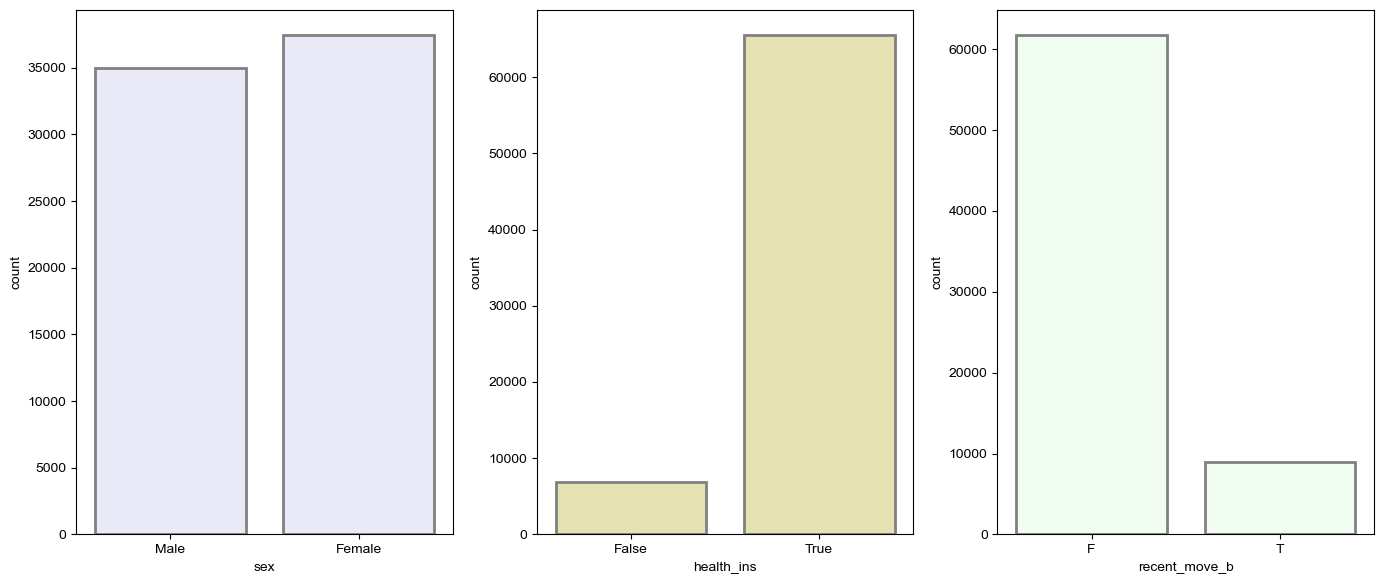

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 6)) 
sns.set_theme(style="whitegrid")
sns.countplot(data=df, x='sex', color="lavender",  edgecolor='gray',linewidth=2, ax=axes[0])
sns.countplot(data=df, x='health_ins', color="palegoldenrod",  edgecolor='gray',linewidth=2, ax=axes[1])
sns.countplot(data=df, x='recent_move_b', color="honeydew",  edgecolor='gray',linewidth=2, ax=axes[2])
plt.tight_layout()

* female and male distribution seems to be similar
* there is a high imbalance in the target variable 'health_ins'
* 'recent_move_b' shows the vast majority of customers didn't move recently

<Axes: xlabel='gas_usage', ylabel='count'>

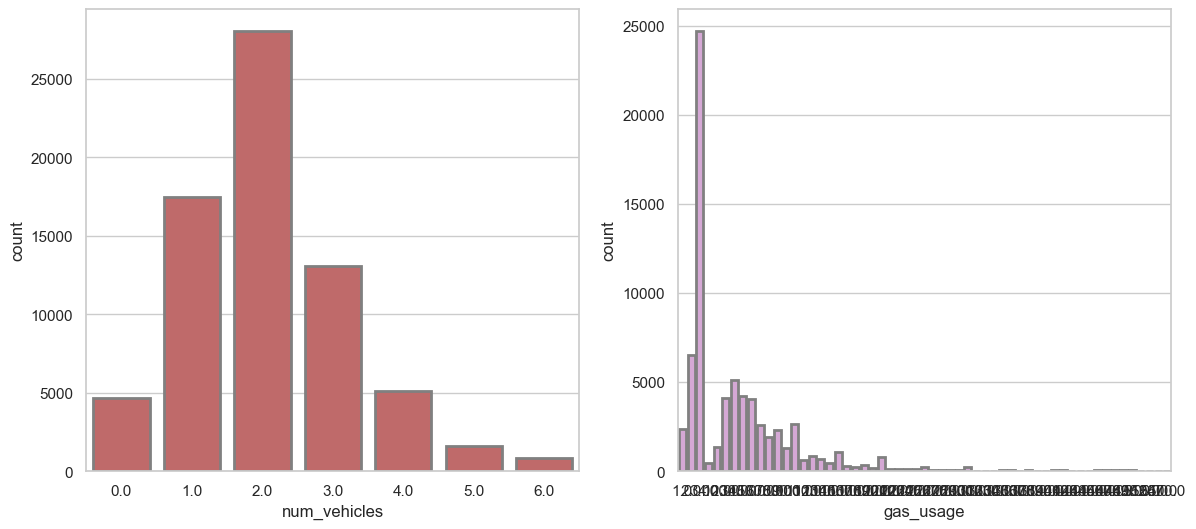

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1x2 grid
sns.set_theme(style="whitegrid")
sns.countplot(data=df, x='num_vehicles', color="indianred",  edgecolor='gray',linewidth=2, ax=axes[0])
sns.countplot(data=df, x='gas_usage', color="plum",  edgecolor='gray',linewidth=2, ax=axes[1])

* The majority of customers owns 2 vehicles
* 'no charge or gas not used' has the highest count out of all the others

# **III - Data Preparation**

### **3.1 Data Consistency**

In [10]:
# Convert column to appropriate data type
df['income'] = df['income'].astype('int')
df[['is_employed', 'health_ins']] = df[['is_employed', 'health_ins']].astype(str)
# Convert to lowercase
string_cols = ['is_employed', 'sex', 'health_ins', 'recent_move_b', 'state_of_res', 'marital_status', 'housing_type']
df[string_cols] = df[string_cols].apply(lambda col: col.str.strip().str.lower())

### **3.2 Handling Missing Values**

The missing values from categorical variables were replaced by their respective mode, while the missing values from numerical variables were replace by the variable's mean value.

In the gas_usage column, we filtered out values greater than or equal to 4, and then replaced the null values with the mean of the remaining values.

In [11]:
# Categorical variables
mode_recent_move = df['recent_move_b'].mode()[0]
df['recent_move_b'] = df['recent_move_b'].fillna(mode_recent_move).astype(str)
mode_marital_status = df['marital_status'].mode()[0]
df['marital_status'] = df['marital_status'].fillna(mode_marital_status).astype(str)
mode_housing = df['housing_type'].mode()[0]
df['housing_type'] = df['housing_type'].fillna(mode_housing).astype(str)
# Numerical variables
mean_vehicles = df['num_vehicles'].mean()
df['num_vehicles'] = df['num_vehicles'].fillna(mean_vehicles).astype(int)
filtered_gas = df['gas_usage'][(df['gas_usage'] >= 4)]
mean_filtered_gas = filtered_gas.mean()
df['gas_usage'] = df['gas_usage'].fillna(mean_filtered_gas).astype(int)

### **3.3 Outlier Management**

For the 'age' column, outliers were identifyed and replaced by the mean as well as all 0 values.

<Axes: xlabel='age', ylabel='Count'>

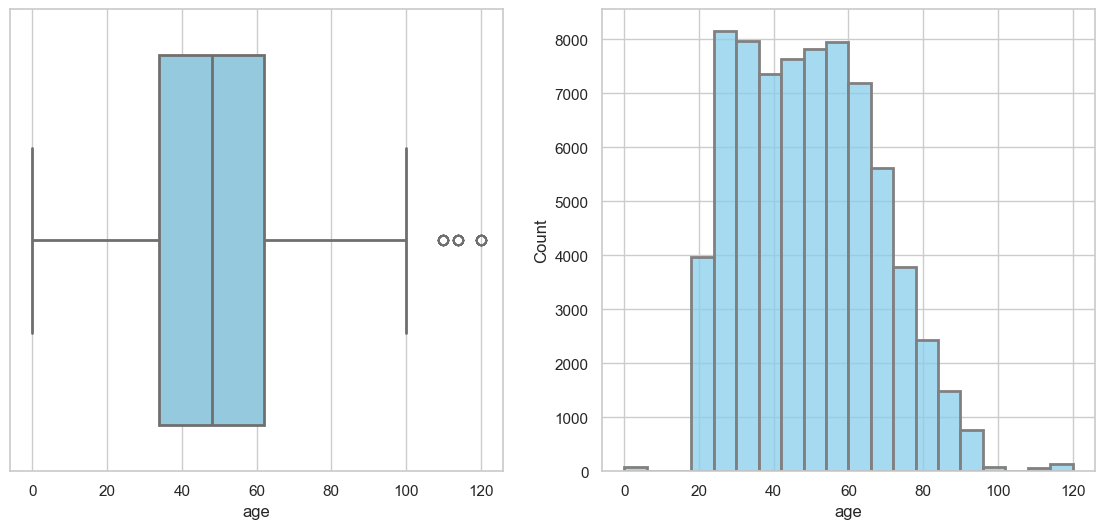

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.set_theme(style="whitegrid")
sns.boxplot(x=df['age'], color='skyblue', fliersize=7, linewidth=2, ax=axes[0])
sns.histplot(data=df, x='age', bins=20, color='skyblue', edgecolor='gray',linewidth=2, ax=axes[1])

In [13]:
# Drop rows where age is 0
df= df[df['age'] != 0]

# Input mean for outliers and Nan values  
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

mean_age = df['age'].mean()

df['age'] = df['age'].apply(lambda x: np.nan if x < lower_bound or x > upper_bound else x)
mean_age = df['age'].mean()
df['age'] = df['age'].fillna(mean_age).astype(int)

<Axes: xlabel='age', ylabel='Count'>

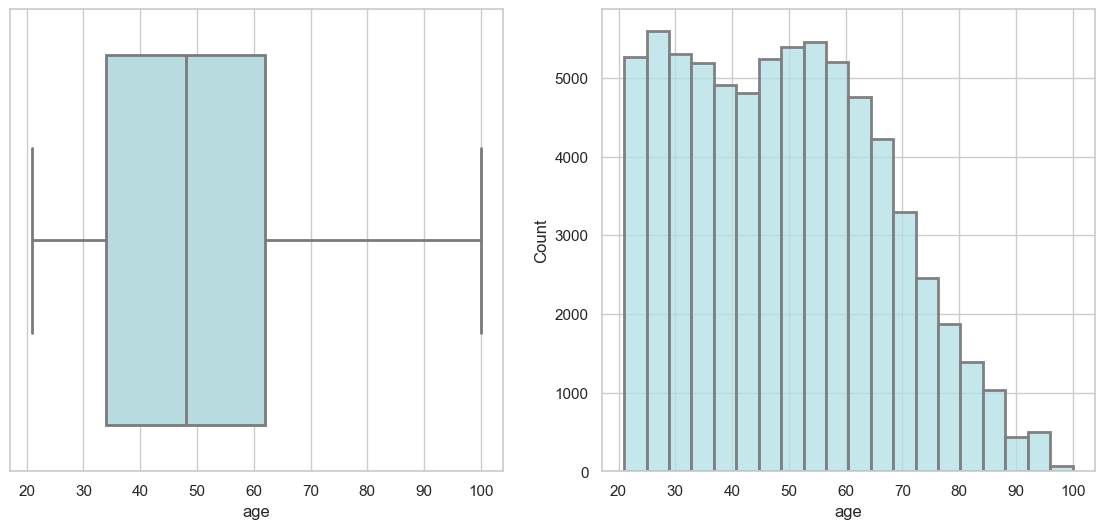

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  
sns.set_theme(style="whitegrid")
sns.boxplot(x=df['age'], color='powderblue', fliersize=7, linewidth=2, ax=axes[0])
sns.histplot(data=df, x='age', bins=20, color='powderblue', edgecolor='gray',linewidth=2, ax=axes[1])

### **3.4 Feature Transformation**

In the context of the problem, the column 'is_employed' has 3 values: true, false and nan. The Nan values correspond to customers who are not in the workforce. Upon analysis of the distribution of these values, we agreed that it would be beneficial to consider just 2 values for 'is_employed' since the 'false' values have a small representation and, in the financial context, it ends up having the same meaning as being unemployed.

<Axes: xlabel='is_employed', ylabel='count'>

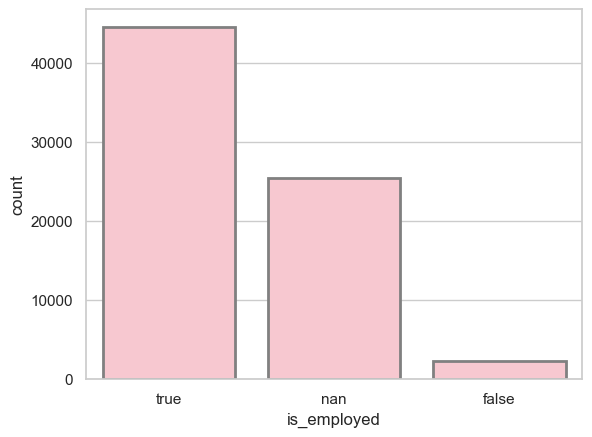

In [15]:
sns.set_theme(style="whitegrid")
sns.countplot(data=df, x='is_employed', color="pink",  edgecolor='gray',linewidth=2)

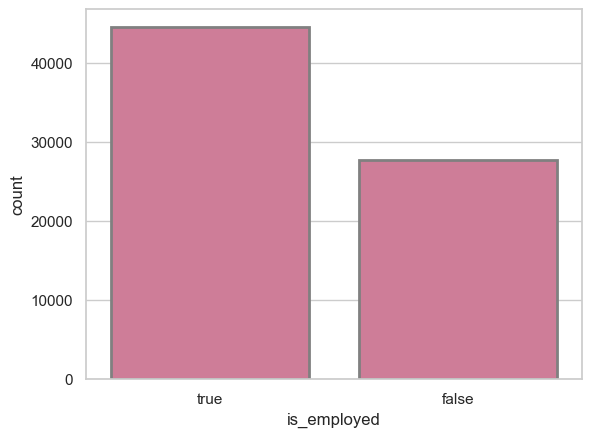

In [16]:
df['is_employed'] = df['is_employed'].replace('nan', np.nan)
df['is_employed'] = df['is_employed'].fillna('false')

sns.set_theme(style="whitegrid")
sns.countplot(data=df, x='is_employed', color="palevioletred",  edgecolor='gray',linewidth=2)
plt.savefig('plot_without_background.png', transparent=True)

The age grouping allowed the understanding of age distribution, that seems to be similar across all three age groups.

Text(0.5, 0, 'Age Group')

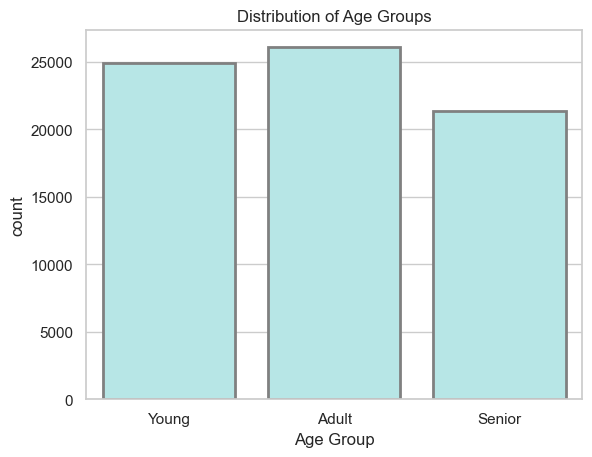

In [17]:
# Dividing age in groups
bins = [20, 39, 59, 100]
labels = ["Young", "Adult", "Senior"]
df.loc[:, 'age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)

sns.countplot(data=df, x='age_group', color="paleturquoise", edgecolor='gray',linewidth=2)
plt.title("Distribution of Age Groups")
plt.xlabel("Age Group")

To make the data more visually comprehensible, we divided the income column into categories and displayed it in a chart. From the visualization, we observed that most people fall into the low income category, followed by middle income and then extremely low income.

Text(0.5, 0, 'Income Group')

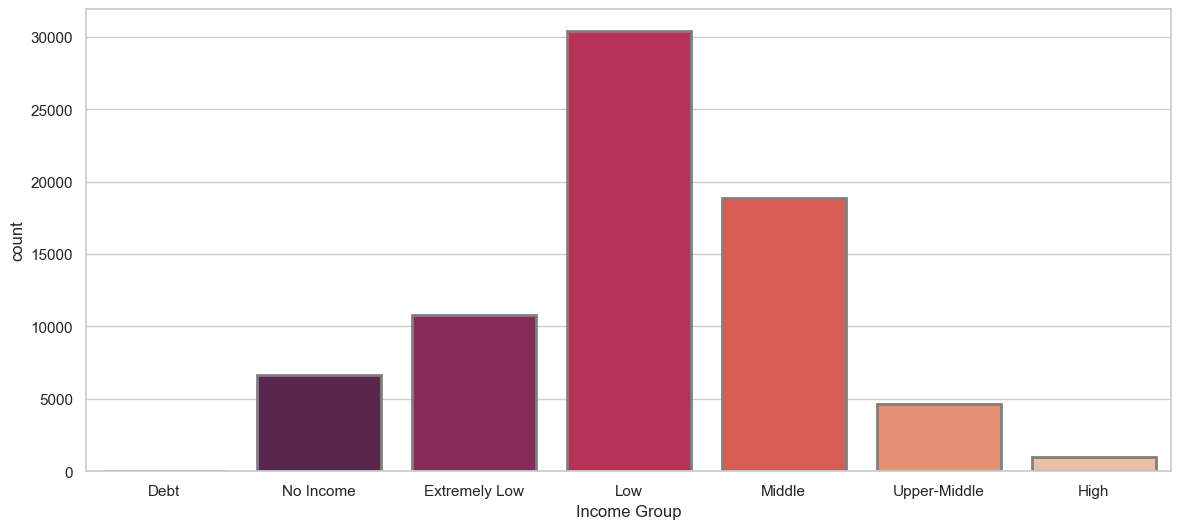

In [18]:
bins = [-19998, -1, 0, 10000, 40000, 100000, 250000, 1e7]
labels = ['Debt', 'No Income', 'Extremely Low', 'Low', 'Middle', 'Upper-Middle', 'High']
df['income_group'] = pd.cut(df['income'], bins=bins, labels=labels, right=True)

plt.figure(figsize=(14, 6))
sns.countplot(data=df, x='income_group', palette='rocket', edgecolor='gray',linewidth=2)
plt.xlabel("Income Group")

Next, we created a new column, 'gas_group', by categorizing the gas_usage values. If a value was in the range of 1, 2, or 3, it was kept unchanged. The remaining values were subdivided into 3 other categories as follows:

<Axes: xlabel='gas_group', ylabel='count'>

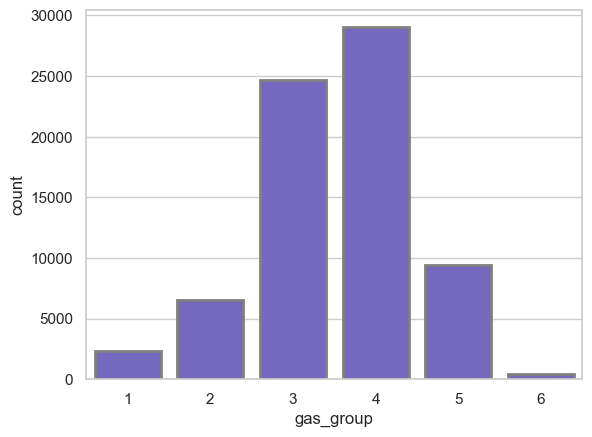

In [19]:
def categorize_gas_usage(value):
    if value in [1, 2, 3]: 
      return value
    else:
        if 4 <= value <= 99:
            return 4  # Low
        elif 100 <= value <= 399:
            return 5  # Medium
        elif 400 <= value <= 999:
            return 6  # High
        else: 
          return None
df['gas_group'] = df['gas_usage'].apply(categorize_gas_usage)

sns.countplot(data=df, x='gas_group', color="slateblue",  edgecolor='gray',linewidth=2)

To compare the variable 'income' with other variables, the following graphics were made:

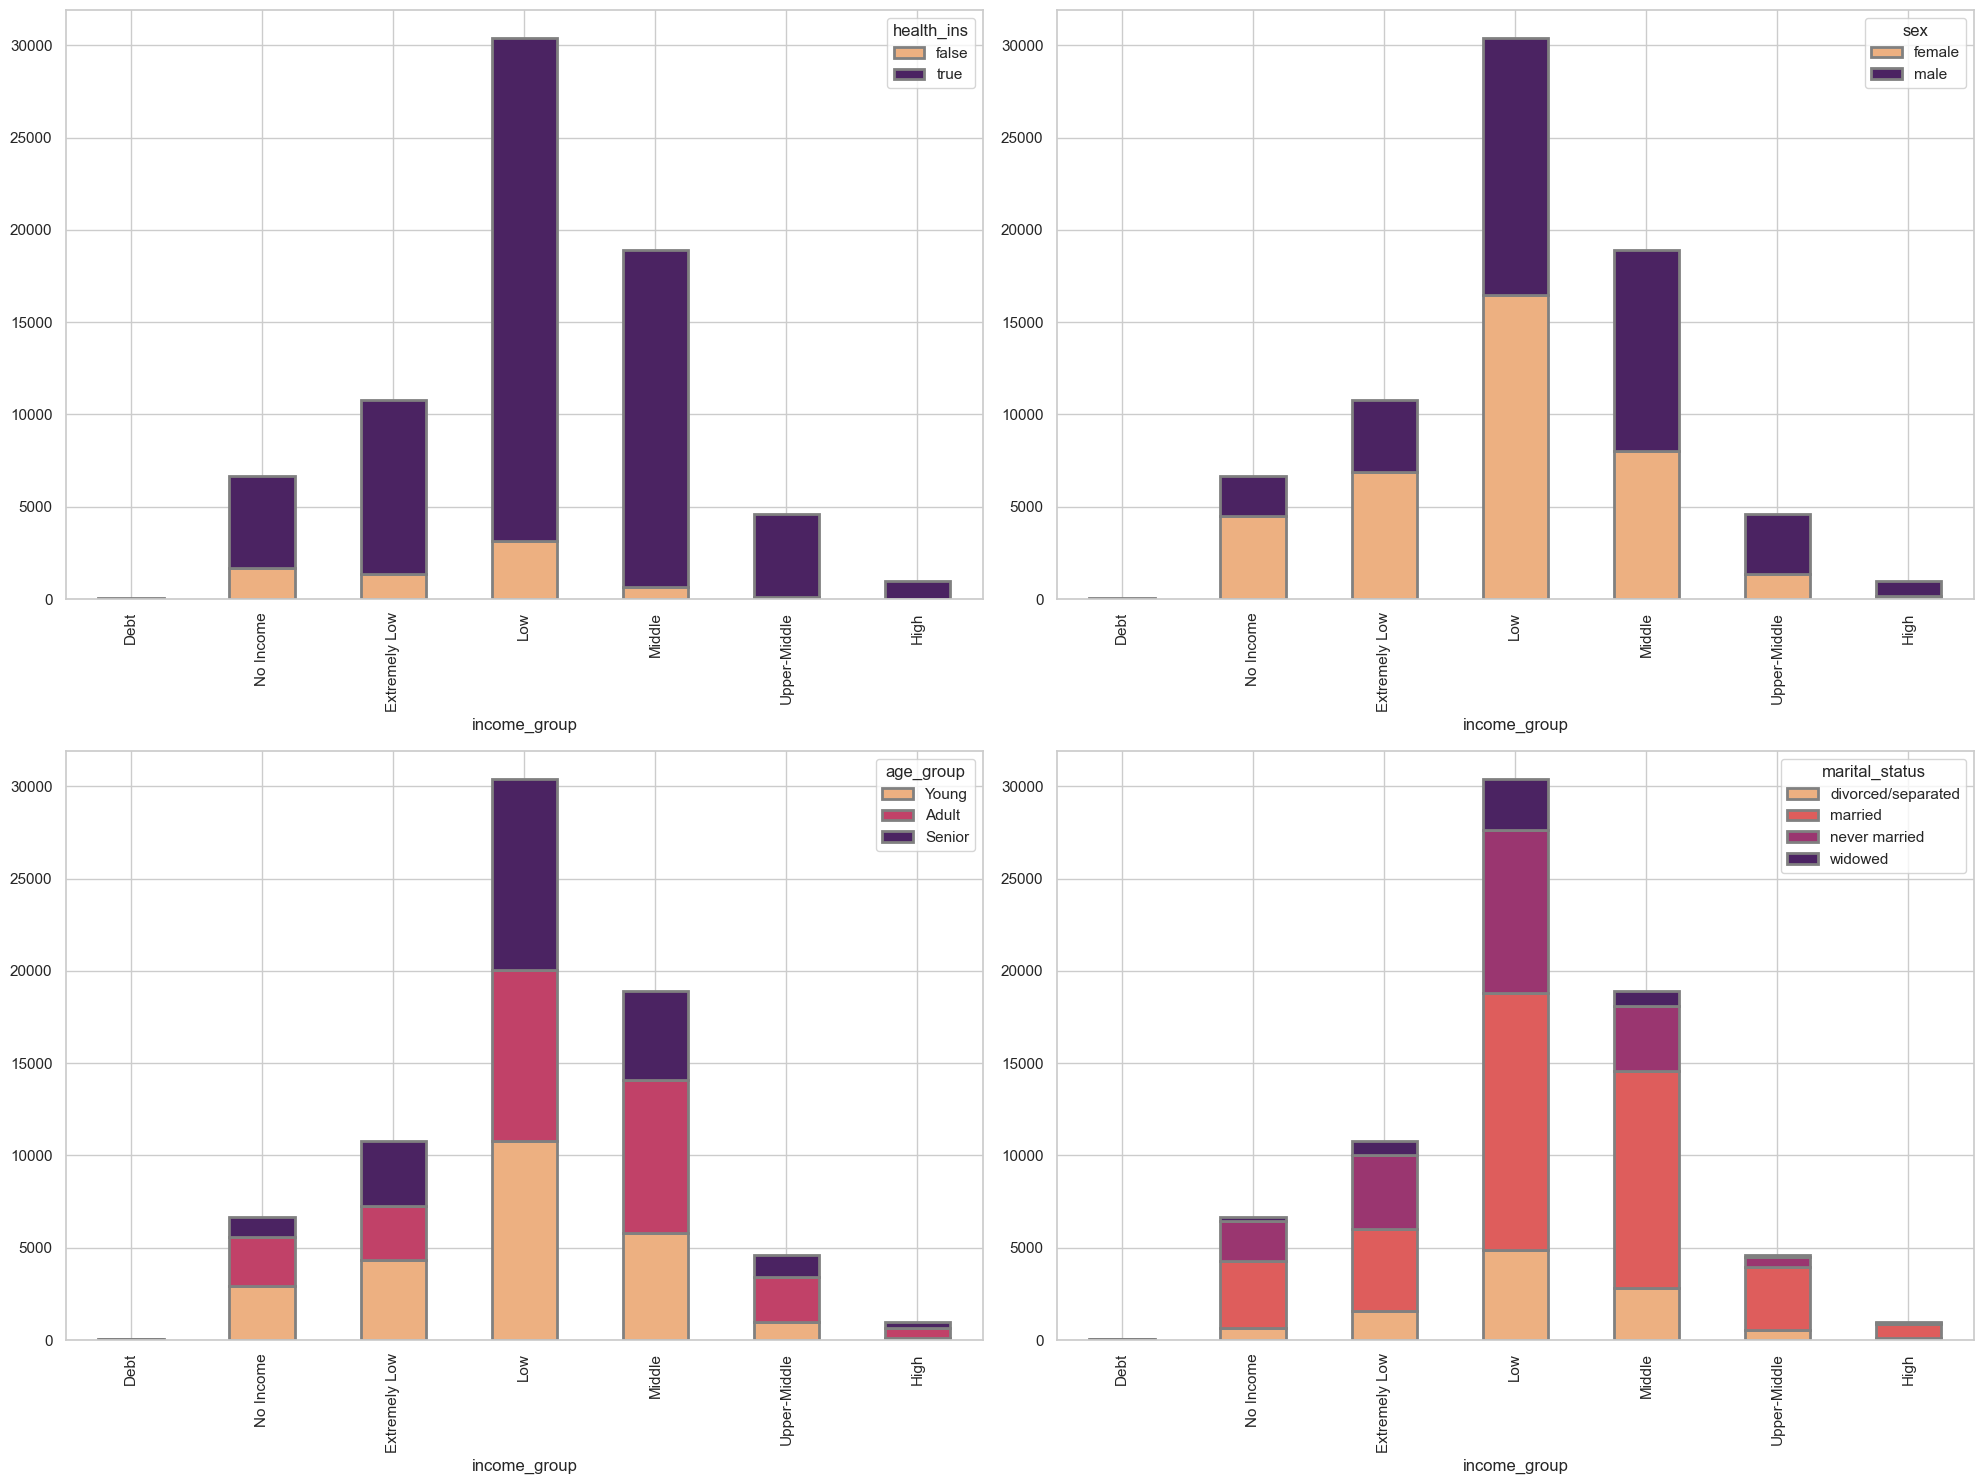

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
pd.crosstab(df['income_group'], df['health_ins']).plot.bar(stacked=True, edgecolor='gray', linewidth=2, colormap="flare", ax=axes[0, 0])
pd.crosstab(df['income_group'], df['sex']).plot.bar(stacked=True, edgecolor='gray', linewidth=2, colormap='flare', ax=axes[0, 1])
pd.crosstab(df['income_group'], df['age_group']).plot.bar(stacked=True, edgecolor='gray', linewidth=2, colormap='flare', ax=axes[1, 0])
pd.crosstab(df['income_group'], df['marital_status']).plot.bar(stacked=True, edgecolor='gray', linewidth=2, colormap='flare', ax=axes[1, 1])
plt.tight_layout()

* Relating the income column to having health insurance, it is clear that higher income classes fully adhere to health insurance, while in lower income classes, although a minority, there are individuals who do not have health insurance.

* Regarding the relationship between gender and income groups, it is more uniform. However, in the lower income classes, females predominate, whereas in higher income classes, males are more prevalent, highlighting the noticeable gender inequality.

* It is noticeable that in the lower income classes, the predominant age group is young, while in the higher income classes, the senior group predominates.

* Marital status and income are also related, as married individuals constitute the majority in the higher income columns, but the different marital status are distributed more evenly across income groups.

To compare health insurance with age, we built a graph that shows that the probability of having health insurance increases with age. 

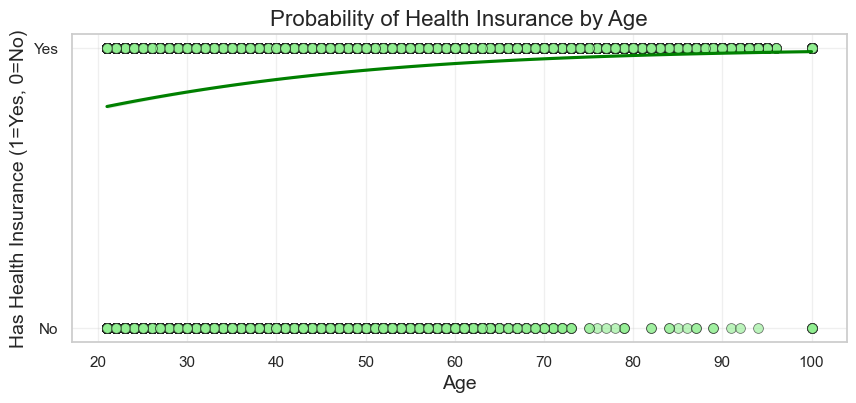

In [21]:
df['health_ins'] = df['health_ins'].replace({'true': '1', 'false': '0'}).astype(int)
plt.figure(figsize=(10, 4))
sns.scatterplot(
    x=df['age'],
    y=df['health_ins'],
    alpha=0.6,  
    s=50,  
    edgecolor="k",
    color="lightgreen")

sns.regplot(
    x="age",
    y="health_ins",
    data=df,
    logistic=True,  
    scatter=False,  
    color="green")

plt.title("Probability of Health Insurance by Age", fontsize=16)
plt.xlabel("Age", fontsize=14)
plt.ylabel("Has Health Insurance (1=Yes, 0=No)", fontsize=14)
plt.yticks([0, 1], ["No", "Yes"])
plt.grid(alpha=0.3)

Younger individuals (20s-40s) have a low likelihood of insurance, while older individuals (60+) are almost guaranteed to have it. There’s a gradual increase in insurance coverage as people reach middle age (40s-50s), reflecting a growing need for health insurance over time.

### **3.5 Scaling and Encoding**

The ‘income’ variable is heavily skewed, so a log transformation was applied after shifting the data upwards by adding the minimum value + 1. This ensured that negative values (representing debt) and zeros (indicating no income) were appropriately transformed. 

<Axes: xlabel='income', ylabel='Count'>

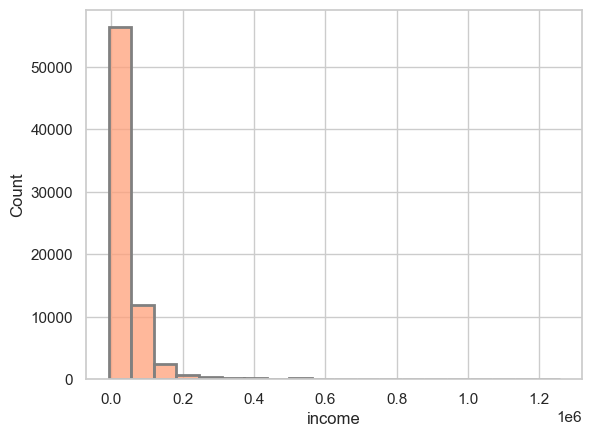

In [22]:
sns.histplot(df['income'], bins=20, kde=False, color="lightsalmon",edgecolor='gray',linewidth=2)

<Axes: xlabel='log_income', ylabel='Count'>

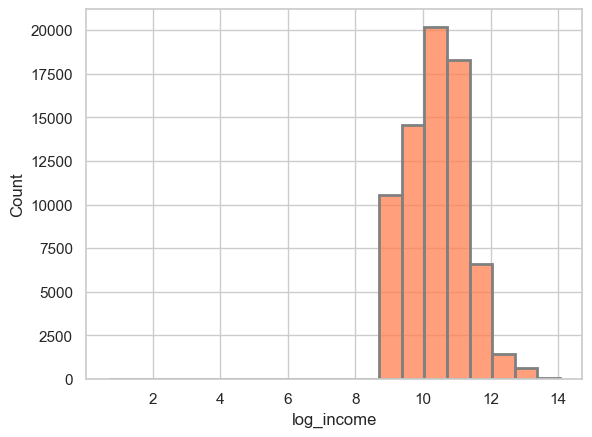

In [23]:
# Adding min value + 1 , so all values > 0
min_income = df['income'].min()
df['income_shifted'] = df['income'] - min_income +1
df['log_income'] = np.log1p(df['income_shifted'])
sns.histplot(df['log_income'], bins=20, kde=False, color="coral",edgecolor='gray',linewidth=2)

The label encoder function was used to convert the categorical data into binary numerical values.

A one-hot encoder was applied to transform the categorical variables into numerical format, creating separate binary columns for each category.

In [24]:
label_encoder = LabelEncoder()
for column in ['sex', 'health_ins', 'recent_move_b','is_employed']:
    df[column] = label_encoder.fit_transform(df[column])

df= pd.get_dummies(df, columns=['marital_status','housing_type','state_of_res'],dtype=int)

After applying the label encoder, the column labels were as follows:
* In the sex column: female=0, male=1
* In the health_ins column: false=0, true=1
* In the recent_move_b column: f=0, t=1

The continuous variables ('age', 'log_income', 'num_vehicles') were standardized using the StandardScaler, making them more comparable for analysis.

In [25]:
scaler = StandardScaler()
continuous_variables= ['age', 'log_income','num_vehicles']
df[continuous_variables] = scaler.fit_transform(df[continuous_variables])

### **3.6 Correlation Analysis**

 To better understand the relationships between all the columns, we created a correlation matrix, which helped identify how each variable is related to the others.

Text(0.5, 1.0, 'Correlation Matrix Heatmap of Numeric Variables')

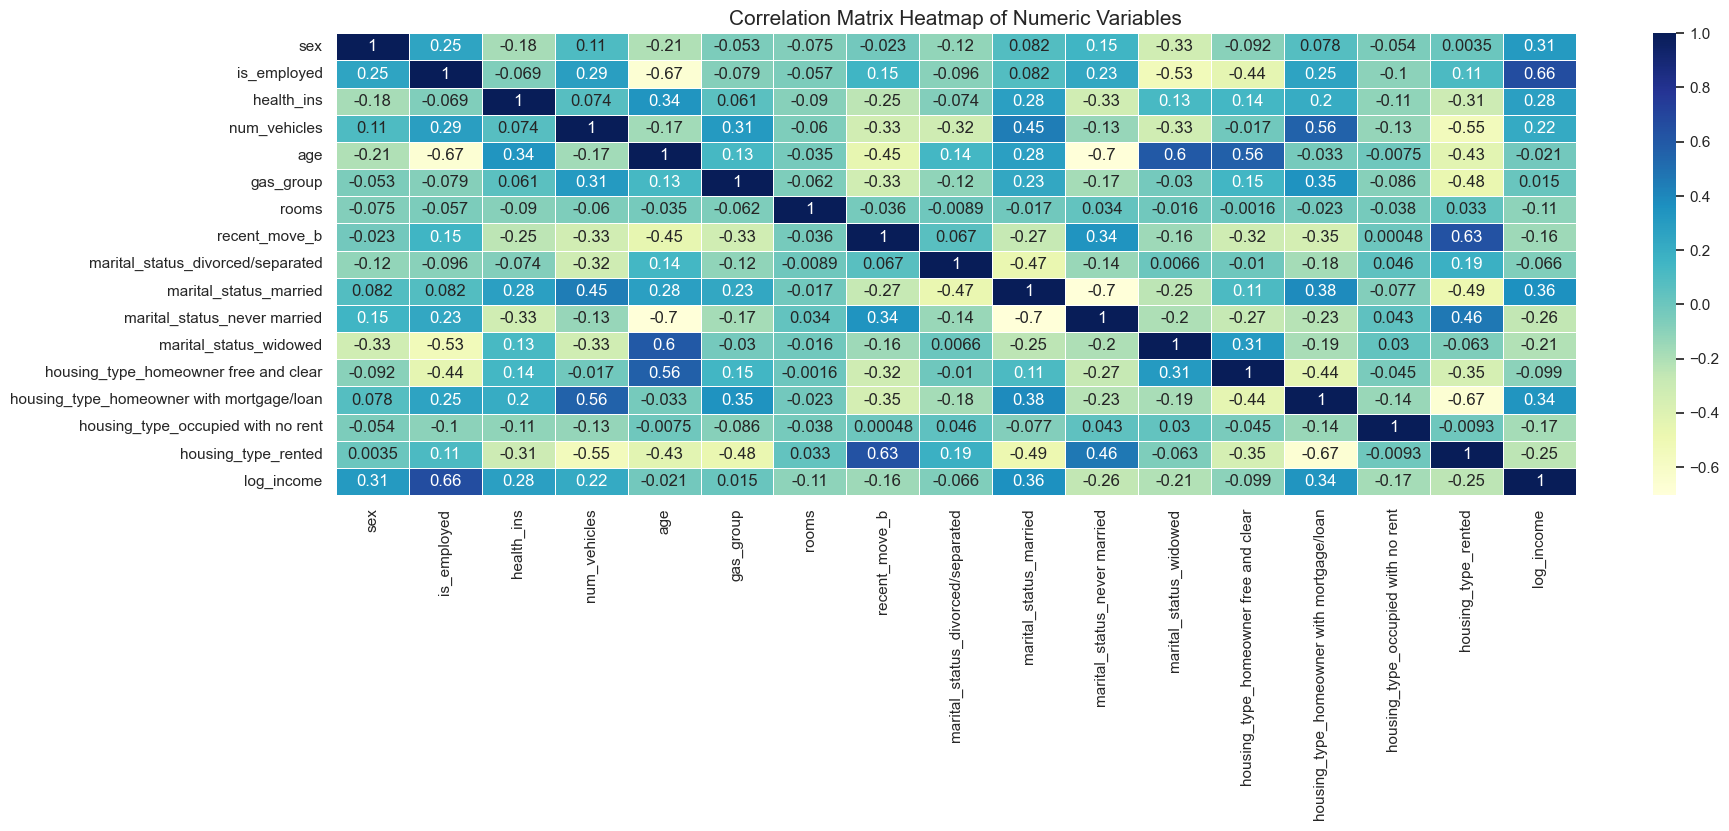

In [26]:
numeric_variables = df[['sex', 'is_employed', 'health_ins', 'num_vehicles', 'age','gas_group', 'rooms', 'recent_move_b','marital_status_divorced/separated', 'marital_status_married','marital_status_never married', 'marital_status_widowed',
           'housing_type_homeowner free and clear', 'housing_type_homeowner with mortgage/loan','housing_type_occupied with no rent', 'housing_type_rented','log_income']].corr()
corr_matrix = numeric_variables.corr()
plt.figure(figsize=(20, 6)) 
sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu', linewidths=0.5)
plt.title('Correlation Matrix Heatmap of Numeric Variables', fontsize=15)

* ‘is_employed’ shows a positive correlation with health insurance, indicating that employed individuals are more likely to be insured. 

* ‘income’ exhibited a weak positive correlation, suggesting that higher income moderately increases the likelihood of insurance. 

* ‘age’ displayed a moderate positive correlation, with older individuals being more likely to have health insurance. 

* ‘marital_status’, particularly being widowed, negatively correlated with health insurance coverage. 

* ‘housing_type’, particularly the rented type, also showed a negative correlation with health insurance.

In [27]:
#Variables that will be used to do the model training
columns_to_select = ['sex', 'is_employed', 'num_vehicles', 'age', 'gas_group', 'rooms', 'recent_move_b',
    'marital_status_divorced/separated', 'marital_status_married',
    'marital_status_never married', 'marital_status_widowed',
    'housing_type_homeowner free and clear',
    'housing_type_homeowner with mortgage/loan',
    'housing_type_occupied with no rent', 'housing_type_rented', 'log_income', 'health_ins']

new_df = df[columns_to_select]

# **IV - Modeling and Evaluation**

Since the target variable ‘health_ins’ is heavily unbalanced, we decided to create 3 diferent versions of the previously prepared data: 
 * Unbalanced 
 * Balanced - Oversample 
 * Balanced - Oversample and Undersample
 
In each of these versions, the dataset was shuffled and divided into train and validation sets using the 80/20 proportion, respectively.
 * The train set was used for calibration of the different model tecniques, using cross validation.
 * The validation set was kept to be used for evaluation of each model after calibration.
 * Each model was trained, evaluated and optimized (hyperparameter tuning).
 * The results are shown through different types of visualizations.

The unbalanced version led to issues like overfitting, biased predictions and was struggling to distinguish differences between classes. 
The version with the minority oversampled achieved worse results than it's hybrid counterpart, probably due to the inflation of the dataset with excessive artificial data, which can amplify the importance of certain features, due to repetitiveness. For these reasons, the "Balanced -Oversample and Undersample" was the version further explored.

Models like Support Vector Machine, Logistic Regression and Neural Network were also trained and tested, achieving similar results to the Decision Tree and Gradient Boosting models, so they were omitted from the notebook.

### **Balanced Data - Oversample + Undersample**

In [28]:
X = new_df.drop(columns=['health_ins'])  
y = new_df['health_ins'] 

smote = SMOTE(sampling_strategy=0.5) # Oversample the minority
undersample = RandomUnderSampler(sampling_strategy=1.0) # Undersample the majority

X_resampled, y_resampled = smote.fit_resample(X, y)
X_resampled, y_resampled = undersample.fit_resample(X_resampled, y_resampled)
X_resampled, y_resampled = shuffle(X_resampled, y_resampled, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

Text(0.5, 1.0, "3. Distribution of 'Health_ins'")

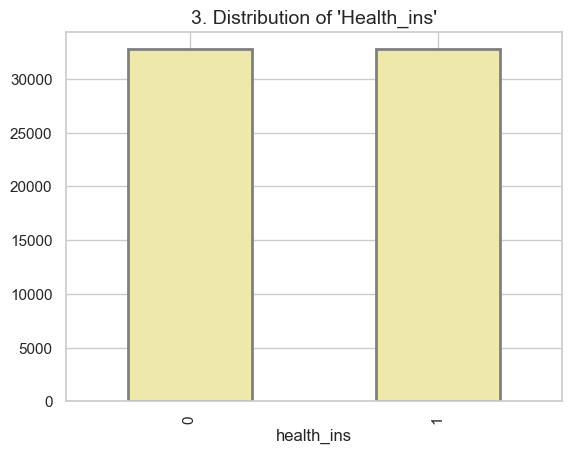

In [29]:
health_ins_counts = pd.Series(y_resampled).value_counts()
health_ins_counts.plot(kind='bar',color="palegoldenrod", edgecolor='gray', linewidth=2)
plt.title("3. Distribution of 'Health_ins'", fontsize=14)

### 4.1 kNN (k-Nearest neighbour)

Text(0.5, 1.0, 'KNN Hyperparameter Tuning')

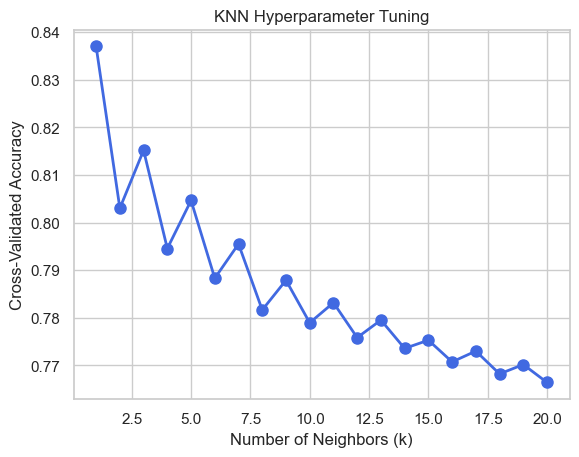

In [30]:
k_values = range(1, 21)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=10, scoring='accuracy')
    cv_scores.append(scores.mean())  

plt.plot(k_values, cv_scores, marker='o', linestyle='-', color='royalblue', linewidth=2, markersize=8, label='Accuracy')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Cross-Validated Accuracy')
plt.title('KNN Hyperparameter Tuning')

Mean CV Accuracy 0.8151655597090608
Precision: 0.888970723623642
Recall: 0.7409453652547575
F1 Score: 0.8082363773332217
ROC-AUC: 0.8246520139343696
Log loss: 6.305437531648396


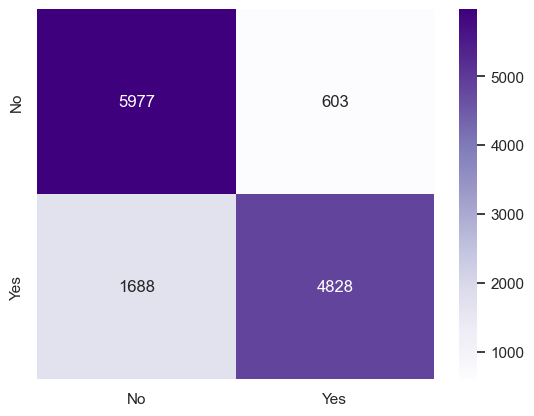

In [31]:
knn = KNeighborsClassifier(n_neighbors=3)
cv_scores = cross_val_score(knn, X_train, y_train, cv=10)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Purples", xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])

print("Mean CV Accuracy", cv_scores.mean())
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_knn))
print("Log loss:", log_loss(y_test, y_pred_knn))

### 4.2 Decision Tree

In [32]:
tree = DecisionTreeClassifier(
    max_depth=10,            
    min_samples_split=50,   
    min_samples_leaf=20,    
    max_leaf_nodes=15,      
    random_state=42)

tree.fit(X_train, y_train)
cv_scores = cross_val_score(tree, X_train, y_train, cv=10)
y_pred_tree=tree.predict(X_test)

print("Mean CV Accuracy", cv_scores.mean())
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall:", recall_score(y_test, y_pred_tree))
print("F1 Score:", f1_score(y_test, y_pred_tree))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_tree))
print("Log loss:", log_loss(y_test, y_pred_tree))

Mean CV Accuracy 0.7300218767794425
Precision: 0.7451628906895982
Recall: 0.6915285451197053
F1 Score: 0.7173445833001671
ROC-AUC: 0.7286670081221627
Log loss: 9.773290560839568


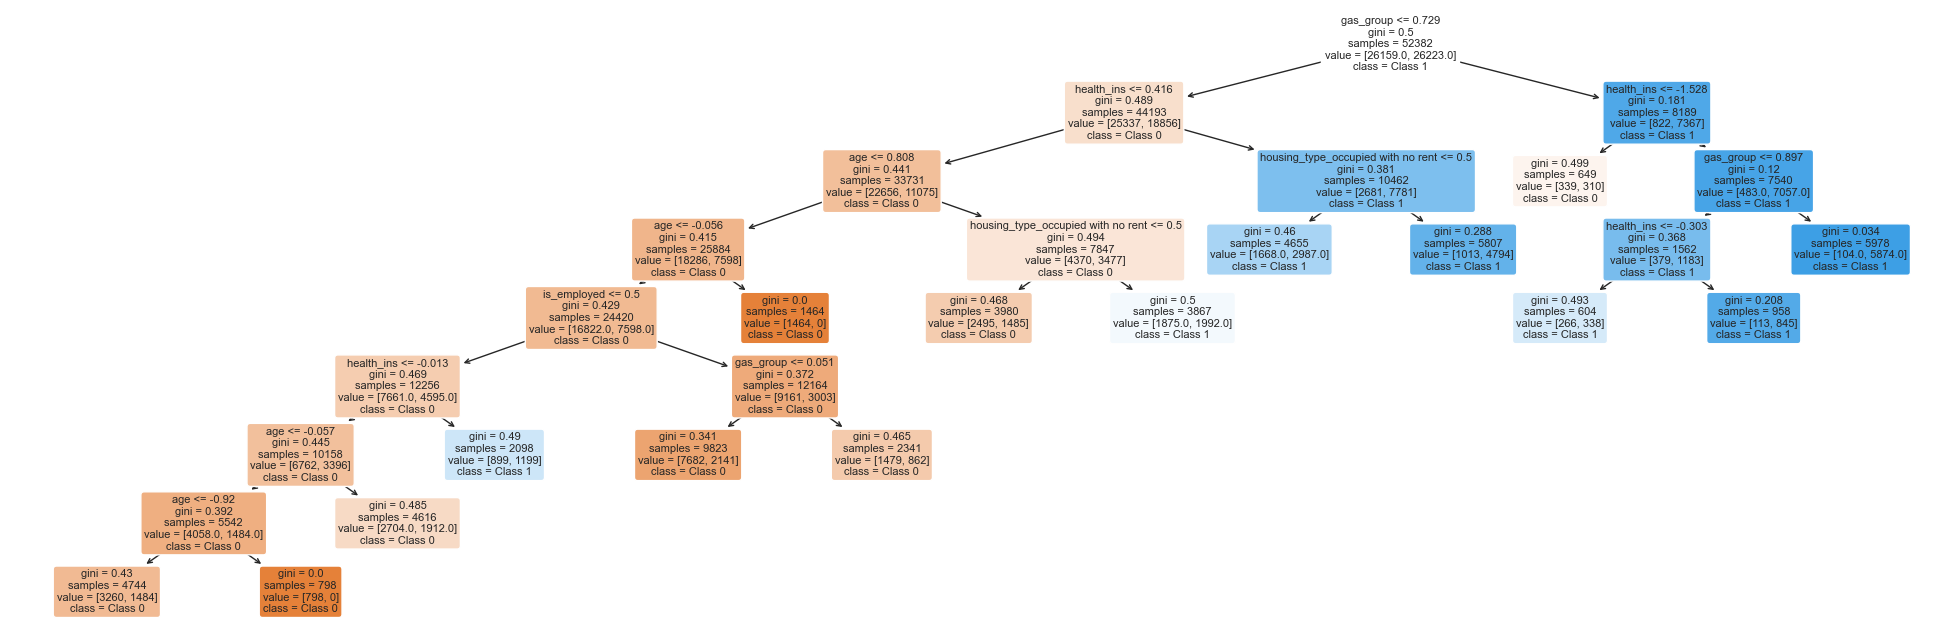

In [33]:
plt.figure(figsize=(25, 8))
plot_tree(tree, feature_names=new_df.columns[1:], class_names=['Class 0', 'Class 1'], filled=True, rounded=True,fontsize=8);

<Axes: >

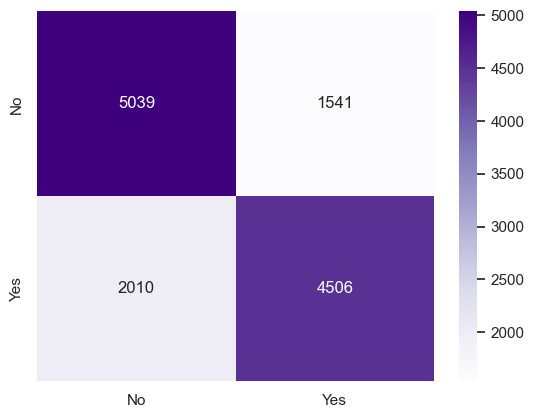

In [34]:
cm_tree = confusion_matrix(y_test, y_pred_tree)
sns.heatmap(cm_tree, annot=True, fmt="d", cmap="Purples", xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])

### 4.3 Random Forest

Mean CV Accuracy 0.8151655597090608
Precision: 0.8795786061588331
Recall: 0.8328729281767956
F1 Score: 0.8555888380892323
ROC-AUC: 0.8599774975230482
Log loss: 5.042148213871611


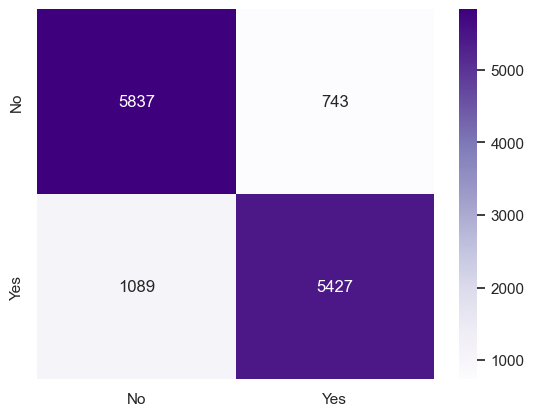

In [35]:
rf_classifier = RandomForestClassifier(n_estimators=200, random_state=42)
cv_scores = cross_val_score(knn, X_train, y_train, cv=10)
rf_classifier.fit(X_train, y_train)
y_pred_rf = rf_classifier.predict(X_test)

cm_ran = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_ran, annot=True, fmt="d", cmap="Purples", xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])

print("Mean CV Accuracy", cv_scores.mean())
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_rf))
print("Log loss:", log_loss(y_test, y_pred_rf))

### 4.4 Gradient Boosting

Mean CV Accuracy 0.7597266834687213
Precision: 0.80962840929892
Recall: 0.6787906691221608
F1 Score: 0.7384589698639286
ROC-AUC: 0.76036797893798
Log loss: 8.622844079726942


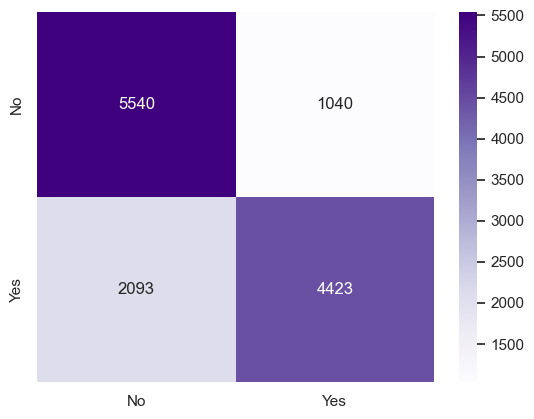

In [36]:
gb_classifier=GradientBoostingClassifier(n_estimators=40)
cv_scores = cross_val_score(gb_classifier, X_train, y_train, cv=10)
gb_classifier.fit(X_train,y_train)
y_pred_gb = gb_classifier.predict(X_test)

cm_gb = confusion_matrix(y_test, y_pred_gb)
sns.heatmap(cm_gb, annot=True, fmt="d", cmap="Purples", xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])

print("Mean CV Accuracy", cv_scores.mean())
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))
print("F1 Score:", f1_score(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_gb))
print("Log loss:", log_loss(y_test, y_pred_gb))

### 4.5 Gaussian Naive Bayes

Mean CV Accuracy 0.7020158639265339
Precision: 0.7580232329198661
Recall: 0.59085328422345
F1 Score: 0.6640793445450626
ROC-AUC: 0.7020375843609651
Log loss: 10.720069483094939


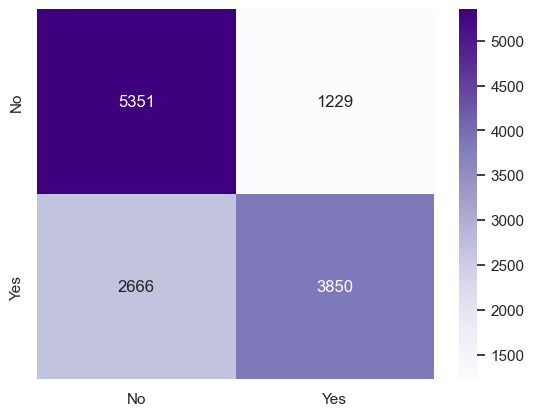

In [37]:
nb_classifier= GaussianNB()
nb_classifier.fit(X_train,y_train)
cv_scores = cross_val_score(nb_classifier, X_train, y_train, cv=10)
y_pred_nb = nb_classifier.predict(X_test)

cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Purples", xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])

print("Mean CV Accuracy", cv_scores.mean())
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall:", recall_score(y_test, y_pred_nb))
print("F1 Score:", f1_score(y_test, y_pred_nb))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_nb))
print("Log loss:", log_loss(y_test, y_pred_nb))

* **Gradient Boosting** - best performing classifier, likely due to its ability to correct past mistakes along the tree ensemble.
* **Gaussian Naive Bayes (Gaussian NB)** - worst performing classifier with the lower F1 and CV accuracy score. This outcome is likely attributed to the fact that Gaussian NB assumes the features follow a normal distribution—a condition not satisfied by our dataset. 
* **K-Nearest Neighbors (KNN) and Random Forest** - highest accuracy during model validation. However, these results did not align with the performance observed when predictions were submitted to Kaggle - high overfitting probability, particularly if the features in the test dataset exhibited different value ranges, if there was an imbalance in the target variable, or if new feature relationships emerged in the test data that were not present in the training set. 

# **V - Model Selection and Conclusions**

Since it was the best performing model, we chose the **Gradient Boosting Classifier** to predict the labels of a new dataset.
This dataset followed the same preprocessing used for the training dataset, to ensure consistency.

In [38]:
os.chdir('C:/Faculdade/Mestrado/Introduction to Data Science/Assignment/')
df_test = pd.read_csv ('customer_test_masked.csv')

### 5.1 Data Understanding

In [39]:
#Checking for duplicates
print(df_test['custid'].size)
print(df_test['custid'].nunique())

#Eliminate first column and index 'custid'
df_test = df_test.drop(df_test.columns[0], axis=1)
df_test = df_test.set_index('custid')

804
804


### 5.2 Data Preparation

In [40]:
# Drop rows where age is 0
df_test= df_test[df_test['age'] != 0]

# Input mean for outliers and Nan values  
Q1 = df_test['age'].quantile(0.25)
Q3 = df_test['age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

mean_age = df_test['age'].mean()

df_test['age'] = df_test['age'].apply(lambda x: np.nan if x < lower_bound or x > upper_bound else x)
mean_age = df_test['age'].mean()
df_test['age'] = df_test['age'].fillna(mean_age).astype(int)

df_test['is_employed']= df_test['is_employed'].astype('str')
df_test['is_employed']= df_test['is_employed'].str.strip().str.lower()

df_test['is_employed'] = df_test['is_employed'].replace('nan', np.nan)
df_test['is_employed'] = df_test['is_employed'].fillna('false')
df_test['is_employed'] = df_test['is_employed'].map({'true': 1, 'false': 0})
df_test['income']= df_test['income'].astype('int')

min_income = df_test['income'].min()
df_test['income_shifted'] = df_test['income'] - min_income +1
df_test['log_income'] = np.log1p(df_test['income_shifted'])

#sex
df_test['sex'] = df_test['sex'].str.strip().str.lower()
#health_ins
df_test['health_ins'] = df_test['health_ins'].astype(str)
df_test['health_ins'] = df_test['health_ins'].str.strip().str.lower()
#recent_move
df_test['recent_move_b'] = df_test['recent_move_b'].str.strip().str.lower()
mode_recent_move = df_test['recent_move_b'].mode()[0]
df_test['recent_move_b'] = df_test['recent_move_b'].fillna(mode_recent_move).astype(str)

label_encoder = LabelEncoder()
for column in ['sex', 'health_ins', 'recent_move_b']:
    df_test[column] = label_encoder.fit_transform(df_test[column])

#state_of_res
df_test['state_of_res'] = df_test['state_of_res'].str.strip().str.lower()
#marital_status
df_test['marital_status'] = df_test['marital_status'].str.strip().str.lower()
mode_marital_status = df_test['marital_status'].mode()[0]
df_test['marital_status'] = df_test['marital_status'].fillna(mode_marital_status).astype(str)
#housing_type
df_test['housing_type'] = df_test['housing_type'].str.strip().str.lower()
mode_housing = df_test['housing_type'].mode()[0]
df_test['housing_type'] = df_test['housing_type'].fillna(mode_housing).astype(str)
df_test= pd.get_dummies(df_test, columns=['marital_status','housing_type','state_of_res'],dtype=int)

#num_vehicles
mean_vehicles = df_test['num_vehicles'].mean()
df_test['num_vehicles'] = df_test['num_vehicles'].fillna(mean_vehicles).astype(int)
#gas_usage
filtered_gas = df_test['gas_usage'][(df_test['gas_usage'] >= 4)]
mean_filtered_gas = filtered_gas.mean()
df_test['gas_usage'] = df_test['gas_usage'].fillna(mean_filtered_gas).astype(int)

def categorize_gas_usage(value):
    if value in [1, 2, 3]:  
      return value
    else:
        if 4 <= value <= 99:
            return 4  
        elif 100 <= value <= 399:
            return 5  
        elif 400 <= value <= 999:
            return 6  
        else: 
          return None
df_test['gas_group'] = df_test['gas_usage'].apply(categorize_gas_usage)

scaler = StandardScaler()
continuous_variables= ['age', 'log_income','num_vehicles']
df_test[continuous_variables] = scaler.fit_transform(df_test[continuous_variables])

columns_to_select = ['sex', 'is_employed', 'num_vehicles', 'age', 'gas_group', 'rooms', 'recent_move_b',
    'marital_status_divorced/separated', 'marital_status_married',
    'marital_status_never married', 'marital_status_widowed',
    'housing_type_homeowner free and clear',
    'housing_type_homeowner with mortgage/loan',
    'housing_type_occupied with no rent', 'housing_type_rented', 'log_income', 'health_ins']

new_df_test = df_test[columns_to_select]

### 5.3 Applying model to test dataframe

In [41]:
df_test = df_test.reset_index()  
X_test = new_df_test.drop(columns='health_ins')
y_test_pred = gb_classifier.predict(X_test)

submission_gb = pd.DataFrame({'custid': df_test['custid'], 'health_ins': y_test_pred})
submission_gb['health_ins'] = submission_gb['health_ins'].map({0:False, 1:True})
submission_gb.to_csv('submission_gb.csv', index=False)
print("Predictions saved to submission_gb.csv")

Predictions saved to submission_gb.csv


### 5.4 Conclusions

* The final dataset predictions achieved an F1-score of 0.74, suggesting a good balance between the precision and recall scores.
* The recall error could mean that the company would potentially lose new customers (the uninsured customers) by not offering them basic or affordable plans
* The precision error (false positives) could lead to promoting premium plans to customers who are not ready for them, affecting customer satisfaction. 
* Overall, the model is a reasonably good fit for the task, allowing the company to provide personalized recommendations with reasonable accuracy for most customers, although further optimization could enhance precision and recall for better decision-making.        

In [ ]:
# Converting to HTML
!pip install nbconvert
!jupyter nbconvert --to html IDS_project_Group_O.ipynb

Defaulting to user installation because normal site-packages is not writeable


[NbConvertApp] Converting notebook IDS_project_Group_O.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 21 image(s).
[NbConvertApp] Writing 1770275 bytes to IDS_project_Group_O.html
